In [1857]:
import pandas as pd
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from scipy.stats import norm
from scipy import stats

all_wines_original = pd.read_csv(r"D:\DataScienceKurs\BlueBerry-Winery\datasets\eda.csv")
red_wine_original = pd.read_csv(r"D:\DataScienceKurs\BlueBerry-Winery\datasets\red_wine_ml.csv")
white_wine_original = pd.read_csv(r"D:\DataScienceKurs\BlueBerry-Winery\datasets\white_wine_ml.csv")
all_wines_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,low,red,74.166,0.099776,32.352941,127.027027
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,low,red,77.322,0.100877,37.313433,125.641026
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,low,red,77.322,0.100877,27.777778,125.641026
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,medium,red,77.322,0.144849,28.333333,87.500000
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,low,red,74.166,0.099776,32.352941,127.027027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,medium,white,88.368,0.070161,26.086957,180.645161
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,low,white,75.744,0.087136,33.928571,145.454545
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,medium,white,74.166,0.087641,27.027027,144.615385
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,medium,white,100.992,0.054460,18.181818,232.727273


In [1858]:
all_wines_original = all_wines_original.drop_duplicates()
all_wines_original.drop("quality", axis =1, inplace=True)
all_wines_original

D:\Users\Olunia\AppData\Local\Temp\ipykernel_31408\3441289596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original.drop("quality", axis =1, inplace=True)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.352941,127.027027
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,low,red,77.322,0.100877,37.313433,125.641026
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,low,red,77.322,0.100877,27.777778,125.641026
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,medium,red,77.322,0.144849,28.333333,87.500000
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.500000,127.027027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,medium,white,88.368,0.070161,26.086957,180.645161
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,low,white,75.744,0.087136,33.928571,145.454545
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,medium,white,74.166,0.087641,27.027027,144.615385
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,medium,white,100.992,0.054460,18.181818,232.727273


In [1859]:
white_wine_original = white_wine_original.drop_duplicates()
white_wine_original.drop("quality", axis =1, inplace = True)
white_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio,sugar_to_sulfur
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,medium,white,69.432,0.100818,26.470588,125.714286,0.048357,0.121765
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,medium,white,74.955,0.084050,10.606061,150.793651,0.621250,0.012121
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,medium,white,79.689,0.101645,30.927835,124.691358,0.144217,0.071134
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,medium,white,78.111,0.092177,25.268817,137.500000,0.117129,0.045699
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,medium,white,75.744,0.081855,22.058824,154.838710,0.142129,0.051471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,medium,white,88.368,0.070161,26.086957,180.645161,0.619463,0.017391
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,low,white,75.744,0.087136,33.928571,145.454545,0.124363,0.047619
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,medium,white,74.166,0.087641,27.027027,144.615385,0.827117,0.010811
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,medium,white,100.992,0.054460,18.181818,232.727273,0.898809,0.010000


### Label Encoder - Wine type

In [1860]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

le = LabelEncoder()
all_wines_original['wine_type'] = le.fit_transform(all_wines_original['wine_type'])

all_wines_original['wine_type'].head()

D:\Users\Olunia\AppData\Local\Temp\ipykernel_31408\864379471.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original['wine_type'] = le.fit_transform(all_wines_original['wine_type'])


0    0
1    0
2    0
3    0
5    0
Name: wine_type, dtype: int32

### Ordinal Encoder - Quality Label

In [1861]:
print(all_wines_original['quality_label'].dtype)
print(all_wines_original['quality_label'].unique())


object
['low' 'medium' 'high']


In [1862]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[["low", "medium", "high"]], dtype=int) # this is how you can define the label order
all_wines_original['quality_label'] = oe.fit_transform(all_wines_original[['quality_label']])
all_wines_original['quality_label'].head()



D:\Users\Olunia\AppData\Local\Temp\ipykernel_31408\3182098399.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_wines_original['quality_label'] = oe.fit_transform(all_wines_original[['quality_label']])


0    0
1    0
2    0
3    1
5    0
Name: quality_label, dtype: int32

### Split the data - wine type

In [1863]:
from sklearn.model_selection import train_test_split

X = all_wines_original.drop('wine_type', axis =1) 
y = all_wines_original['wine_type'] # --> what you're trying to predict

print("original:", all_wines_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (5320, 17) 
X: (5320, 16) 
y: (5320,)


### Define the split

In [1864]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
917             6.8              0.41         0.31            8.80      0.084   
1725            7.4              0.39         0.23            7.00      0.033   
2377            6.9              0.22         0.37           15.00      0.053   
5635            7.3              0.33         0.22            1.40      0.041   
1550            7.1              0.68         0.00            2.30      0.087   
...             ...               ...          ...             ...        ...   
5992            6.4              0.18         0.28           17.05      0.047   
5706            6.8              0.30         0.26           20.30      0.037   
5454            5.9              0.18         0.29            4.60      0.032   
6351            5.1              0.25         0.36            1.30      0.035   
3546            5.7              0.45         0.42            1.10      0.051   

      free_sulfur_dioxide  

### Feature Scaling

In [1865]:
scaler = StandardScaler()
X_train_scaled1 = scaler.fit_transform(X_train)
X_test_scaled1 = scaler.transform(X_test)

### Building a model

#### Logistic Regression

In [1866]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000) 

In [1867]:
LR_model.fit(X_train_scaled1, y_train)

LogisticRegression(max_iter=1000)

In [1868]:
preds = LR_model.predict(X_test_scaled1)
preds

array([1, 1, 0, ..., 1, 0, 1])

In [1869]:
y_test

4882    1
1981    1
636     0
5052    1
4555    1
       ..
3954    1
1443    0
1081    0
401     0
2284    1
Name: wine_type, Length: 1064, dtype: int32

In [1870]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, preds)
acc

0.9924812030075187

### Random Forest

In [1871]:
from sklearn.ensemble import RandomForestClassifier

In [1872]:
RF_clf = RandomForestClassifier(random_state=420)

In [1873]:
RF_clf.fit(X_train_scaled1, y_train)

RandomForestClassifier(random_state=420)

In [1874]:
preds = RF_clf.predict(X_test_scaled1)
preds

array([1, 1, 0, ..., 0, 0, 1])

In [1875]:
acc = accuracy_score(y_test, preds)
acc

0.9962406015037594

### Split the data Quality Label

In [1876]:
from sklearn.model_selection import train_test_split

X = all_wines_original.drop('quality_label', axis =1) 
y = all_wines_original['quality_label'] # --> what you're trying to predict

print("original:", all_wines_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (5320, 17) 
X: (5320, 16) 
y: (5320,)


#### Define the split

In [1877]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
917             6.8              0.41         0.31            8.80      0.084   
1725            7.4              0.39         0.23            7.00      0.033   
2377            6.9              0.22         0.37           15.00      0.053   
5635            7.3              0.33         0.22            1.40      0.041   
1550            7.1              0.68         0.00            2.30      0.087   
...             ...               ...          ...             ...        ...   
5992            6.4              0.18         0.28           17.05      0.047   
5706            6.8              0.30         0.26           20.30      0.037   
5454            5.9              0.18         0.29            4.60      0.032   
6351            5.1              0.25         0.36            1.30      0.035   
3546            5.7              0.45         0.42            1.10      0.051   

      free_sulfur_dioxide  

In [1878]:
scaler = StandardScaler()
X_train_scaled2 = scaler.fit_transform(X_train)
X_test_scaled2 = scaler.transform(X_test)

### Logistic Regression - QL

In [1879]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000) 
LR_model.fit(X_train_scaled2, y_train)
lr_preds = LR_model.predict(X_test_scaled2)
lr_preds

array([0, 0, 0, ..., 1, 1, 0])

In [1880]:
y_test

4882    1
1981    1
636     0
5052    1
4555    1
       ..
3954    1
1443    0
1081    1
401     1
2284    0
Name: quality_label, Length: 1064, dtype: int32

In [1881]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, lr_preds)
acc

0.7406015037593985

In [1882]:
# # Logistic Regression - faster in one go
# from sklearn.linear_model import LogisticRegression
# # define model
# LR_model = LogisticRegression(max_iter=1000)
# # fit model
# LR_model.fit(X_train, y_train)
# # make predictions
# LR_preds = LR_model.predict(X_test)

### Random Forest - QL

In [1883]:
from sklearn.ensemble import RandomForestClassifier
RF_clf = RandomForestClassifier(random_state=420)
RF_clf.fit(X_train_scaled2, y_train)

RandomForestClassifier(random_state=420)

In [1884]:
rf_preds = RF_clf.predict(X_test_scaled2)
rf_preds

array([1, 0, 0, ..., 1, 1, 0])

In [1885]:
acc = accuracy_score(y_test, rf_preds)
acc

0.7593984962406015

In [1886]:
# # Random Forest - in one go
# from sklearn.ensemble import RandomForestClassifier
# # define model
# RF_clf = RandomForestClassifier(random_state=420)
# # fit model
# RF_clf.fit(X_train, y_train)
# # make predictions
# RF_preds = RF_clf.predict(X_test)

## Evaluation Matrix

#### Confusion Matrix - Logistic Regression

In [1887]:
print("Confusion matrix:")
print(confusion_matrix(y_test, lr_preds))

Confusion matrix:
[[250 156   0]
 [ 95 538   0]
 [  0  25   0]]


In [1888]:
compare = pd.concat([pd.Series(lr_preds), y_test.reset_index(drop=True)], axis="columns")

def self_cm(row):
    pred, actual = row.items()
    if pred[1] == 1:
        return "TP" if pred[1] == actual[1] else "FP"
    else:
        return "TN" if pred[1] == actual[1] else "FN"

CM_col = compare.apply(self_cm, axis=1)

CM_col.value_counts()

TP    538
TN    250
FP    181
FN     95
Name: count, dtype: int64

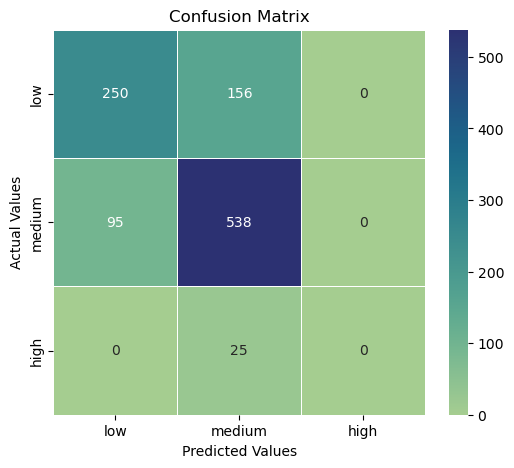

In [1889]:
# Compute confusion matrix
cm = confusion_matrix(y_test, lr_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [1890]:
print("Accuracy score:", accuracy_score(y_test, lr_preds))

Accuracy score: 0.7406015037593985


In [1891]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.72      0.62      0.67       406
      medium       0.75      0.85      0.80       633
        high       0.00      0.00      0.00        25

    accuracy                           0.74      1064
   macro avg       0.49      0.49      0.49      1064
weighted avg       0.72      0.74      0.73      1064



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1892]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, lr_preds))

0.4530367909048071


### Confusion Matrix - Random Forest

In [1893]:
print("Confusion matrix:")
print(confusion_matrix(y_test, rf_preds))

Confusion matrix:
[[262 144   0]
 [ 87 546   0]
 [  0  25   0]]


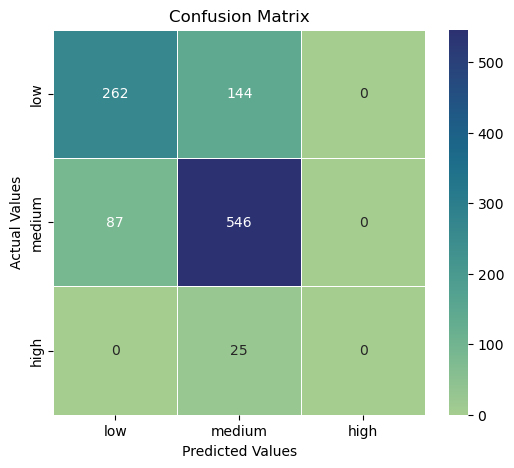

In [1894]:
# Compute confusion matrix
cm = confusion_matrix(y_test, rf_preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

In [1895]:
print("Accuracy score:", accuracy_score(y_test, rf_preds))

Accuracy score: 0.7593984962406015


In [1896]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_preds, target_names=["low","medium","high"], zero_division = 0)) # zero_division = 0 means that when dividing by 0 it will equal 0. It is better option (than = 1) for accurate reporting of model performance.

              precision    recall  f1-score   support

         low       0.72      0.62      0.67       406
      medium       0.75      0.85      0.80       633
        high       0.00      0.00      0.00        25

    accuracy                           0.74      1064
   macro avg       0.49      0.49      0.49      1064
weighted avg       0.72      0.74      0.73      1064



In [1897]:
from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, lr_preds))

0.4530367909048071


### Imbalanced Data - SMOTE

In [1898]:
from imblearn.over_sampling import SMOTE

In [1899]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import numpy as np

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Apply SMOTE to the training data
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print before and after class distribution
print("Original class distribution:", np.bincount(y_train))
print("Resampled class distribution:", np.bincount(y_train_resampled))

Original class distribution: [1378 2232  114]
Resampled class distribution: [2232 2232 2232]


In [1900]:
# Step 3: Train Machine Learning Model (Random Forest)
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_resampled, y_train_resampled)

# Step 4: Predict & Evaluate Model
y_pred = clf.predict(X_test)


# Print Confusion Matrix and Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[435 174   1]
 [213 684  50]
 [  1  29   9]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69       610
           1       0.77      0.72      0.75       947
           2       0.15      0.23      0.18        39

    accuracy                           0.71      1596
   macro avg       0.53      0.56      0.54      1596
weighted avg       0.72      0.71      0.71      1596



In [1901]:
print("Accuracy score:", accuracy_score(y_test, y_pred))

# Accuracy = (Correct Predictions) / (Total Predictions)

# If the total number of predictions increased significantly, accuracy can decrease, even if the model is making more correct predictions overall.

Accuracy score: 0.706766917293233


In [1902]:

from sklearn.metrics import cohen_kappa_score
print(cohen_kappa_score(y_test, y_pred))

0.42938906659067977


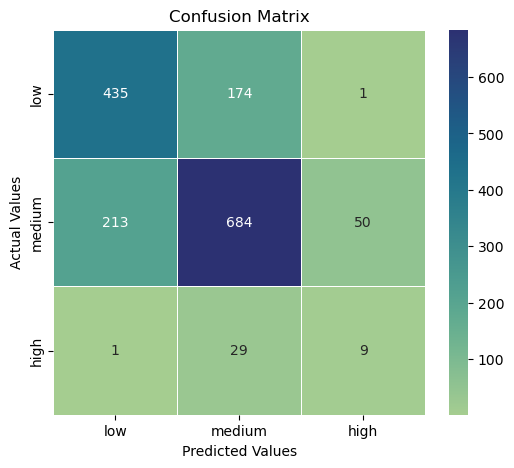

In [1903]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="crest", linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()

### WHITE WINE

In [1904]:
white_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio,sugar_to_sulfur
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,medium,white,69.432,0.100818,26.470588,125.714286,0.048357,0.121765
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,medium,white,74.955,0.084050,10.606061,150.793651,0.621250,0.012121
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,medium,white,79.689,0.101645,30.927835,124.691358,0.144217,0.071134
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,medium,white,78.111,0.092177,25.268817,137.500000,0.117129,0.045699
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,medium,white,75.744,0.081855,22.058824,154.838710,0.142129,0.051471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,medium,white,88.368,0.070161,26.086957,180.645161,0.619463,0.017391
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,low,white,75.744,0.087136,33.928571,145.454545,0.124363,0.047619
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,medium,white,74.166,0.087641,27.027027,144.615385,0.827117,0.010811
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,medium,white,100.992,0.054460,18.181818,232.727273,0.898809,0.010000


In [1905]:
le = LabelEncoder()
white_wine_original['wine_type'] = le.fit_transform(white_wine_original['wine_type'])

white_wine_original['wine_type'].head()


0    0
1    0
2    0
3    0
6    0
Name: wine_type, dtype: int32

In [1906]:
oe = OrdinalEncoder(categories=[["low", "medium", "high"]], dtype=int) # this is how you can define the label order
white_wine_original['quality_label'] = oe.fit_transform(white_wine_original[['quality_label']])
white_wine_original['quality_label'].head()

0    1
1    1
2    1
3    1
6    1
Name: quality_label, dtype: int32

In [1907]:
from sklearn.model_selection import train_test_split

X = white_wine_original.drop('quality_label', axis =1) 
y = white_wine_original['quality_label'] # --> what you're trying to predict

print("original:", white_wine_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (3961, 19) 
X: (3961, 18) 
y: (3961,)


In [1908]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
541             7.2             0.460         0.65           10.40      0.050   
2361            8.2             0.250         0.46            3.75      0.050   
1386            5.6             0.490         0.13            4.50      0.039   
929             6.1             0.360         0.58           15.00      0.044   
3834            6.5             0.410         0.22            4.80      0.052   
...             ...               ...          ...             ...        ...   
950             7.6             0.345         0.26            1.90      0.043   
686             6.8             0.220         0.35            5.50      0.043   
470             8.6             0.370         0.70           12.15      0.039   
1299            7.8             0.230         0.28            4.75      0.042   
3669            5.9             0.370         0.32            1.60      0.029   

      free_sulfur_dioxide  

In [1909]:
# from imblearn.over_sampling import BorderlineSMOTE

# borderline_smote = BorderlineSMOTE(random_state=42)
# X_resampled, y_resampled = borderline_smote.fit_resample(X_train, y_train)

### SMOTE imbalanced data

In [1910]:

# # Split into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Apply SMOTE to the training data
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # Print before and after class distribution
# print("Original class distribution:", np.bincount(y_train))
# print("Resampled class distribution:", np.bincount(y_train_resampled))

### Data Standarisation

In [1911]:
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data (do NOT fit again)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression White Wine

In [1912]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000) 

In [1913]:
from sklearn.linear_model import LogisticRegression
LR_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [1914]:
preds = LR_model.predict(X_test_scaled)
preds

array([1, 1, 1, ..., 1, 0, 1])

In [1915]:
y_test

2631    1
1115    2
388     1
2307    0
4461    1
       ..
1389    1
3181    1
4843    0
4021    0
4184    1
Name: quality_label, Length: 1189, dtype: int32

In [1916]:
from sklearn.metrics import accuracy_score 

acc = accuracy_score(y_test, preds)
acc

0.7283431455004206

### Random Forest

In [1917]:
RF_clf = RandomForestClassifier(random_state=42)


In [1918]:
RF_clf.fit(X_train_scaled, y_train)
preds = RF_clf.predict(X_test_scaled)
preds

array([1, 1, 1, ..., 1, 0, 1])

In [1919]:
acc = accuracy_score(y_test, preds)
acc

0.7636669470142977

In [1920]:
from sklearn.metrics import confusion_matrix

In [1921]:
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

Confusion matrix:
[[267 121   0]
 [116 639   1]
 [  1  42   2]]


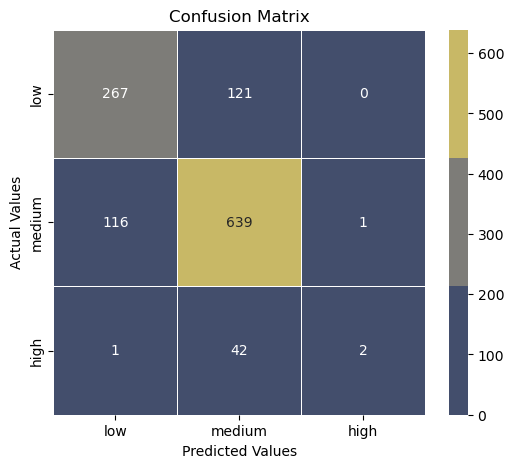

In [1922]:
# Compute confusion matrix

cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()



In [1923]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.70      0.69      0.69       388
      medium       0.80      0.85      0.82       756
        high       0.67      0.04      0.08        45

    accuracy                           0.76      1189
   macro avg       0.72      0.53      0.53      1189
weighted avg       0.76      0.76      0.75      1189



In [1924]:
print("Accuracy score:", accuracy_score(y_test, preds))
from sklearn.metrics import cohen_kappa_score
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, preds)}")

Accuracy score: 0.7636669470142977
Cohen Kappa Score: 0.4924530824175657


### Will removing not relevant columns help?

In [1925]:
white_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio,sugar_to_sulfur
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,1,0,69.432,0.100818,26.470588,125.714286,0.048357,0.121765
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,1,0,74.955,0.084050,10.606061,150.793651,0.621250,0.012121
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,1,0,79.689,0.101645,30.927835,124.691358,0.144217,0.071134
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,1,0,78.111,0.092177,25.268817,137.500000,0.117129,0.045699
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,3.18,0.47,9.6,1,0,75.744,0.081855,22.058824,154.838710,0.142129,0.051471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,1,0,88.368,0.070161,26.086957,180.645161,0.619463,0.017391
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,0,0,75.744,0.087136,33.928571,145.454545,0.124363,0.047619
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,1,0,74.166,0.087641,27.027027,144.615385,0.827117,0.010811
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,1,0,100.992,0.054460,18.181818,232.727273,0.898809,0.010000


In [1926]:
white_wine_dropped_columns = white_wine_original.drop(['fixed_acidity','alcohol_g_per_L','sulphates','density_to_sugar_ratio','pH','acidity_to_alcohol_ratio','SO2_ratio','sugar_to_sulfur'], axis = 1)

In [1927]:
white_wine_dropped_columns

,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,alcohol,quality_label,wine_type,alc_acid_ratio
0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,8.8,1,0,125.714286
1,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,9.5,1,0,150.793651
2,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,10.1,1,0,124.691358
3,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,9.9,1,0,137.500000
6,0.32,0.16,7.0,0.045,30.0,136.0,0.99490,9.6,1,0,154.838710
...,...,...,...,...,...,...,...,...,...,...,...
4893,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,11.2,1,0,180.645161
4894,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,9.6,0,0,145.454545
4895,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,9.4,1,0,144.615385
4896,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,12.8,1,0,232.727273


In [1928]:
from sklearn.model_selection import train_test_split

X = white_wine_dropped_columns.drop('quality_label', axis = 1) 
y = white_wine_dropped_columns['quality_label'] 

print("original:", white_wine_dropped_columns.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (3961, 11) 
X: (3961, 10) 
y: (3961,)


In [1929]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=420)
print(X_train, X_test)

# # Split into training and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# # Apply SMOTE to the training data
# smote = SMOTE(sampling_strategy='auto', random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # Print before and after class distribution
# print("Original class distribution:", np.bincount(y_train))
# print("Resampled class distribution:", np.bincount(y_train_resampled))

# scaler = StandardScaler()
# X_train_scaled3 = scaler.fit_transform(X_train)
# X_test_scaled3 = scaler.transform(X_test)

from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled3 = scaler.fit_transform(X_train)

# Transform the test data (do NOT fit again)
X_test_scaled3 = scaler.transform(X_test)


      volatile_acidity  citric_acid  residual_sugar  chlorides  \
4726             0.480         0.48            1.80      0.035   
852              0.180         0.36            1.30      0.036   
815              0.300         0.17            2.80      0.040   
4515             0.280         0.26            2.80      0.039   
2302             0.260         0.18            7.00      0.055   
...                ...          ...             ...        ...   
950              0.345         0.26            1.90      0.043   
686              0.220         0.35            5.50      0.043   
470              0.370         0.70           12.15      0.039   
1299             0.230         0.28            4.75      0.042   
3669             0.370         0.32            1.60      0.029   

      free_sulfur_dioxide  total_sulfur_dioxide  density  alcohol  wine_type  \
4726                 35.0                  96.0  0.99121     12.2          0   
852                  40.0                 117.0

Logistic Regression after DS and removing columns

In [1930]:
LR_model = LogisticRegression(max_iter=1000) 
LR_model.fit(X_train_scaled3, y_train)
preds = LR_model.predict(X_test_scaled3)
y_test
acc = accuracy_score(y_test, preds)
acc

0.7245206861755802

Random Forest after Data Standarisation and removing columns

In [1931]:
from sklearn.ensemble import RandomForestClassifier
RF_clf = RandomForestClassifier(random_state=42)
RF_clf.fit(X_train_scaled3, y_train)
preds = RF_clf.predict(X_test_scaled3)
acc = accuracy_score(y_test, preds)
from sklearn.metrics import cohen_kappa_score
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, preds)}")
acc

Cohen Kappa Score: 0.47161405465699935


0.7588294651866802

In [1932]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds, target_names=["low","medium","high"]))

              precision    recall  f1-score   support

         low       0.68      0.65      0.67       317
      medium       0.79      0.85      0.82       638
        high       0.67      0.06      0.10        36

    accuracy                           0.76       991
   macro avg       0.71      0.52      0.53       991
weighted avg       0.75      0.76      0.75       991



### Red Wine

In [1933]:
red_wine_original = red_wine_original.drop(['quality'], axis =1)

In [1934]:
red_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.352941,127.027027,0.525158
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,low,red,77.322,0.100877,37.313433,125.641026,0.383385
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,low,red,77.322,0.100877,27.777778,125.641026,0.433478
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,medium,red,77.322,0.144849,28.333333,87.500000,0.525263
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.352941,127.027027,0.525158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,low,red,82.845,0.074839,72.727273,169.354839,0.497450
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,medium,red,88.368,0.066766,76.470588,189.830508,0.452327
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,medium,red,86.790,0.072589,72.500000,174.603175,0.432930
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,low,red,80.478,0.073312,72.727273,172.881356,0.497735


In [1935]:
red_wine_original = red_wine_original.drop_duplicates()
red_wine_original

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label,wine_type,alcohol_g_per_L,acidity_to_alcohol_ratio,SO2_ratio,alc_acid_ratio,density_to_sugar_ratio
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.352941,127.027027,0.525158
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,low,red,77.322,0.100877,37.313433,125.641026,0.383385
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,low,red,77.322,0.100877,27.777778,125.641026,0.433478
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,medium,red,77.322,0.144849,28.333333,87.500000,0.525263
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,low,red,74.166,0.099776,32.500000,127.027027,0.554333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,medium,red,74.955,0.090721,73.684211,139.705882,0.524479
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,low,red,82.845,0.074839,72.727273,169.354839,0.497450
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,medium,red,88.368,0.066766,76.470588,189.830508,0.452327
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,low,red,80.478,0.073312,72.727273,172.881356,0.497735


In [1936]:
le = LabelEncoder()
red_wine_original['wine_type'] = le.fit_transform(red_wine_original['wine_type'])

red_wine_original['wine_type'].head()

oe = OrdinalEncoder(categories=[["low", "medium", "high"]], dtype=int) # this is how you can define the label order
red_wine_original['quality_label'] = oe.fit_transform(red_wine_original[['quality_label']])
red_wine_original['quality_label'].head()

D:\Users\Olunia\AppData\Local\Temp\ipykernel_31408\3038893045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_wine_original['wine_type'] = le.fit_transform(red_wine_original['wine_type'])
D:\Users\Olunia\AppData\Local\Temp\ipykernel_31408\3038893045.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  red_wine_original['quality_label'] = oe.fit_transform(red_wine_original[['quality_label']])


0    0
1    0
2    0
3    1
5    0
Name: quality_label, dtype: int32

In [1937]:
from sklearn.model_selection import train_test_split

X = red_wine_original.drop('quality_label', axis = 1) 
y = red_wine_original['quality_label'] 

print("original:", red_wine_original.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (1359, 18) 
X: (1359, 17) 
y: (1359,)


In [1938]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
1066            6.6              0.52         0.08             2.4      0.070   
1276            8.5              0.40         0.40             6.3      0.050   
1440            7.2              0.37         0.32             2.0      0.062   
403            11.4              0.60         0.49             2.7      0.085   
874            10.4              0.38         0.46             2.1      0.104   
...             ...               ...          ...             ...        ...   
937            12.0              0.63         0.50             1.4      0.071   
664            12.1              0.40         0.52             2.0      0.092   
447             9.3              0.48         0.29             2.1      0.127   
1286            7.1              0.16         0.44             2.5      0.068   
1111            5.4              0.42         0.27             2.0      0.092   

      free_sulfur_dioxide  

In [1939]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled4 = scaler.fit_transform(X_train)

# Transform the test data (do NOT fit again)
X_test_scaled4 = scaler.transform(X_test)

In [1940]:
RF_clf = RandomForestClassifier(random_state=42)
RF_clf.fit(X_train_scaled4, y_train)
preds = RF_clf.predict(X_test_scaled4)
acc = accuracy_score(y_test, preds)
acc
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, preds, target_names=["low","medium","high"]))

Confusion matrix:
[[101  28   0]
 [ 31 109   1]
 [  0   2   0]]
              precision    recall  f1-score   support

         low       0.77      0.78      0.77       129
      medium       0.78      0.77      0.78       141
        high       0.00      0.00      0.00         2

    accuracy                           0.77       272
   macro avg       0.52      0.52      0.52       272
weighted avg       0.77      0.77      0.77       272



In [1941]:
acc

0.7720588235294118

In [1942]:
import numpy as np

n_estimators = np.arange(10,201,10)
max_depth = np.arange(5, 55, 5)
min_samples_split = np.arange(2, 15, 2)
max_features = ["sqrt", "log2", None]

param_grid = {
  'n_estimators': n_estimators,
  'max_depth': max_depth,
  'min_samples_split': min_samples_split,
  'max_features': max_features,
}

param_grid

{'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
        140, 150, 160, 170, 180, 190, 200]),
 'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
 'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
 'max_features': ['sqrt', 'log2', None]}

In [1943]:
from sklearn.model_selection import RandomizedSearchCV

# redefine model
RF_clf = RandomForestClassifier(random_state=420)

RS_grid = RandomizedSearchCV(estimator=RF_clf, param_distributions=param_grid, n_iter=10)
RS_grid

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=420),
                   param_distributions={'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [1944]:
RS_grid.fit(X_train_scaled4, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=420),
                   param_distributions={'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [1945]:
print(
  'best score: ', RS_grid.best_score_,
  '\nparams: ', RS_grid.best_params_
)

best score:  0.7359531560478586 
params:  {'n_estimators': 100, 'min_samples_split': 6, 'max_features': 'sqrt', 'max_depth': 40}


In [1946]:
import pandas as pd

grid_results = pd.concat([
  pd.DataFrame(RS_grid.cv_results_["params"]),
  pd.DataFrame(RS_grid.cv_results_["mean_test_score"], columns=["Accuracy"])
], axis=1)

grid_results

,n_estimators,min_samples_split,max_features,max_depth,Accuracy
0,60,10,sqrt,30,0.735057
1,140,10,None,35,0.720348
2,140,6,sqrt,15,0.731366
3,110,12,None,25,0.726800
4,100,6,sqrt,40,0.735953
5,50,4,log2,20,0.729527
6,100,10,None,45,0.725878
7,40,2,sqrt,25,0.723080
8,90,12,None,50,0.726787
9,110,14,None,35,0.727713


### Dropping columns

In [1947]:
red_wine_dropped_columns = red_wine_original.drop(['residual_sugar','pH','total_sulfur_dioxide','free_sulfur_dioxide','alcohol_g_per_L','alc_acid_ratio','density_to_sugar_ratio','acidity_to_alcohol_ratio'], axis = 1)

In [1948]:
red_wine_dropped_columns

,fixed_acidity,volatile_acidity,citric_acid,chlorides,density,sulphates,alcohol,quality_label,wine_type,SO2_ratio
0,7.4,0.700,0.00,0.076,0.99780,0.56,9.4,0,0,32.352941
1,7.8,0.880,0.00,0.098,0.99680,0.68,9.8,0,0,37.313433
2,7.8,0.760,0.04,0.092,0.99700,0.65,9.8,0,0,27.777778
3,11.2,0.280,0.56,0.075,0.99800,0.58,9.8,1,0,28.333333
5,7.4,0.660,0.00,0.075,0.99780,0.56,9.4,0,0,32.500000
...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,0.068,0.99651,0.82,9.5,1,0,73.684211
1594,6.2,0.600,0.08,0.090,0.99490,0.58,10.5,0,0,72.727273
1595,5.9,0.550,0.10,0.062,0.99512,0.76,11.2,1,0,76.470588
1597,5.9,0.645,0.12,0.075,0.99547,0.71,10.2,0,0,72.727273


In [1949]:
from sklearn.model_selection import train_test_split

X = red_wine_dropped_columns.drop('quality_label', axis = 1) 
y = red_wine_dropped_columns['quality_label'] 

print("original:", red_wine_dropped_columns.shape, "\nX:", X.shape, "\ny:", y.shape)

original: (1359, 10) 
X: (1359, 9) 
y: (1359,)


In [1950]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=420)
print(X_train, X_test)

      fixed_acidity  volatile_acidity  citric_acid  chlorides  density  \
1447            6.8              0.67         0.00      0.080  0.99701   
550             6.8              0.51         0.01      0.074  0.99580   
889            10.7              0.90         0.34      0.112  1.00289   
1010            8.9              0.28         0.45      0.067  0.99354   
404             7.7              0.69         0.05      0.075  0.99740   
...             ...               ...          ...        ...      ...   
937            12.0              0.63         0.50      0.071  0.99791   
664            12.1              0.40         0.52      0.092  1.00000   
447             9.3              0.48         0.29      0.127  0.99680   
1286            7.1              0.16         0.44      0.068  0.99328   
1111            5.4              0.42         0.27      0.092  0.99471   

      sulphates  alcohol  wine_type  SO2_ratio  
1447       0.74      9.7          0  56.410256  
550        0.

In [1951]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler(feature_range=(0,1))

# Fit and transform the training data
X_train_scaled5 = scaler.fit_transform(X_train)

# Transform the test data (do NOT fit again)
X_test_scaled5 = scaler.transform(X_test)

In [1952]:
RF_clf = RandomForestClassifier(random_state=42)
RF_clf.fit(X_train_scaled5, y_train)
preds = RF_clf.predict(X_test_scaled5)
acc = accuracy_score(y_test, preds)
print("Confusion matrix:")
print(confusion_matrix(y_test, preds))

from sklearn.metrics import classification_report
print(classification_report(y_test, preds, target_names=["low","medium","high"]))

Confusion matrix:
[[125  39   0]
 [ 42 130   0]
 [  0   4   0]]
              precision    recall  f1-score   support

         low       0.75      0.76      0.76       164
      medium       0.75      0.76      0.75       172
        high       0.00      0.00      0.00         4

    accuracy                           0.75       340
   macro avg       0.50      0.51      0.50       340
weighted avg       0.74      0.75      0.75       340



d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
d:\Users\Olunia\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [1953]:
acc

0.75

In [1954]:
print(f"Cohen Kappa Score: {cohen_kappa_score(y_test, preds)}")

Cohen Kappa Score: 0.5056110578896948


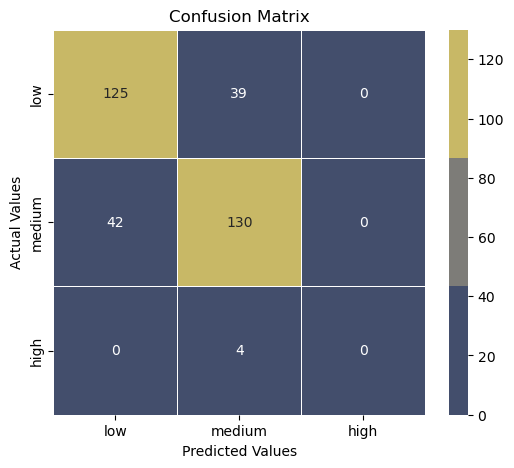

In [1955]:
# Compute confusion matrix

cm = confusion_matrix(y_test, preds)

# Convert to DataFrame
cm_df = pd.DataFrame(cm, 
                     index=['low', 'medium', 'high'], 
                     columns=['low', 'medium', 'high'])

# Load the cividis colormap from Matplotlib
cividis = plt.get_cmap("cividis")

# Choose specific gradient positions (values from 0 to 1)
colors = [cividis(0.25), cividis(0.5), cividis(0.8)]  # Adjust these values to change the colors

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
# Apply these colors to the heatmap
sns.heatmap(cm_df, annot=True, fmt="d", cmap=sns.color_palette(colors, as_cmap=True), linewidths=0.5, cbar=True)

# Labels and title
plt.title("Confusion Matrix")
plt.ylabel("Actual Values")
plt.xlabel("Predicted Values")
plt.show()


#### Hyperparameter tuning

In [1956]:
import numpy as np

n_estimators = np.arange(10,201,10)
max_depth = np.arange(5, 55, 5)
min_samples_split = np.arange(2, 15, 2)
max_features = ["sqrt", "log2", None]

param_grid = {
  'n_estimators': n_estimators,
  'max_depth': max_depth,
  'min_samples_split': min_samples_split,
  'max_features': max_features,
}

param_grid

{'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
        140, 150, 160, 170, 180, 190, 200]),
 'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
 'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
 'max_features': ['sqrt', 'log2', None]}

In [1957]:
from sklearn.model_selection import RandomizedSearchCV

# redefine model
RF_clf = RandomForestClassifier(random_state=420)

RS_grid = RandomizedSearchCV(estimator=RF_clf, param_distributions=param_grid, n_iter=10)
RS_grid

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=420),
                   param_distributions={'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [1958]:
RS_grid.fit(X_train_scaled5, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=420),
                   param_distributions={'max_depth': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50]),
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14]),
                                        'n_estimators': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200])})

In [1959]:
print(
  'best score: ', RS_grid.best_score_,
  '\nparams: ', RS_grid.best_params_
)

# best score:  0.7295311376992346 
# params:  {'n_estimators': 100, 'min_samples_split': 4, 'max_features': None, 'max_depth': 40}

# best score 0.7350441804422272 
# params:  {'n_estimators': 40, 'min_samples_split': 14, 'max_features': 'log2', 'max_depth': 5}


best score:  0.7251714478895007 
params:  {'n_estimators': 130, 'min_samples_split': 4, 'max_features': 'sqrt', 'max_depth': 5}


In [1960]:
import pandas as pd

grid_results = pd.concat([
  pd.DataFrame(RS_grid.cv_results_["params"]),
  pd.DataFrame(RS_grid.cv_results_["mean_test_score"], columns=["Accuracy"])
], axis=1)

grid_results

,n_estimators,min_samples_split,max_features,max_depth,Accuracy
0,10,6,log2,35,0.692780
1,70,6,log2,40,0.714363
2,40,4,None,10,0.707529
3,30,12,None,50,0.715382
4,130,4,sqrt,5,0.725171
5,180,4,log2,10,0.717309
6,140,14,sqrt,20,0.719279
7,90,6,None,10,0.709500
8,110,10,log2,40,0.719294
9,160,6,None,50,0.709490
